In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from farming_data.projection import Project
from forward_process.generate_noised_data import GenerateNoisedData
from initial_distributions.gaussian_mixture import GaussianMixture

from forward_process.generate_noised_data import BetaSchedule
from scipy.integrate import simpson


def binder_cumulant(distros):

    # vectorizado
    moment2 = np.mean(distros**2, axis=1)
    moment4 = np.mean(distros**4, axis=1)

    binder = 1 - moment4 / (3 * moment2**2)

    #binder_smooth = savgol_filter(binder, window_length=51, polyorder=3)

    return binder

KeyboardInterrupt: 

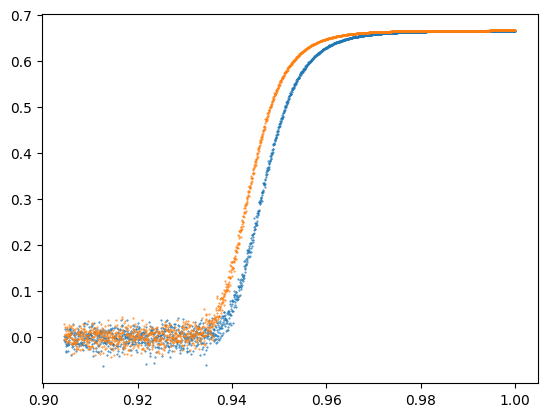

In [86]:
fig, ax = plt.subplots()
n,t = 10000, 2000

def theta(time):

    beta = BetaSchedule(time)

    theta = np.exp(-0.5*simpson(beta, dx = 0.01))

    return theta

thetas = np.zeros(2000)
for step in range(1,2000):
    thetas[step] = theta(step)

for d in range(1,100):

    distros,_,_ = GenerateNoisedData(timesteps=t, ndata=n, dimension=d, 
                             initial_distribution=GaussianMixture, c=0)

    normalized_unity = np.ones(d) / np.sqrt(d)

    projections = np.tensordot(distros, normalized_unity, axes=([1], [0])).T


    binder = binder_cumulant(projections)


    #print(thetas.shape)
    #print(binder.shape)
    if d%10 == 0:
        ax.scatter(thetas[1:], binder[1:], s=0.2, label=f'$d={d}$')

ax.legend()